# 03 · CEvNS event simulation

            Replaces `sim_script/CEvNS_Sim.ipynb` and the CEvNS-only path of
            `Data_load_reshape.ipynb`.  We

            1. load the CEvNS multiplicity spectrum,
            2. sample events uniformly inside the fiducial volume,
            3. simulate the S2 pattern + pe info,
            4. CNN-reconstruct the position and compute the pattern likelihood + the
               space-time correlation against the muon record.

In [1]:
# Auto-discover the package even if the notebook is launched from outside the repo.
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

In [2]:
from relics_de_sim import DESimConfig, Pipeline
cfg = DESimConfig.from_yaml('../configs/cevns_sim.yaml')
print('cevns_e_spectrum:', cfg.paths.cevns_e_spectrum)

cevns_e_spectrum: /home/leiyang/TPC_DE_SIm-main/data/cevns_sim_20_3e.npz


## 1 – Load muons (provides the time range CEvNS samples in)

In [3]:
from pathlib import Path
muon_files = [Path(cfg.paths.muon_track_dir) / f'muon_track.{i}.npy' for i in range(2)]
pipe = Pipeline(cfg, rng=np.random.default_rng(7))
pipe.load_muon_tracks(muon_files)
print(f'time range: {pipe.time_range_s:.1f} s')

Reading muon files: 100%|██████████| 2/2 [00:00<00:00, 115.87it/s]


time range: 819.6 s


## 2 – Sample CEvNS events

In [4]:
try:
    pipe.simulate_cevns()
    for arr in pipe.cevns_points:
        if len(arr):
            print(f'n_e={int(arr["num_e"][0])}: {len(arr)} events')
except ImportError as exc:
    print('CNN inference unavailable:', exc)

/home/leiyang/TPC_DE_SIm-main/relics_de_sim/recon.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = self._torch.load(checkpoint_path, map_location=self.device)


Using device: cuda
model loaded from epoch /home/leiyang/TPC_DE_SIm-main/model/Regression/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 1/1 [00:00<00:00, 18078.90it/s]


total samples:  1 , using a 128 batch for data loader


100%|██████████| 1/1 [00:00<00:00,  7.82it/s]


...

model loaded from epoch /home/leiyang/TPC_DE_SIm-main/model/Regression/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 379/379 [00:00<00:00, 260939.14it/s]


total samples:  379 , using a 128 batch for data loader


space-time correlation: 100%|██████████| 1/1 [00:00<00:00, 27.88it/s]

n_e=2: 1 events
n_e=3: 237316 events
n_e=4: 125231 events
n_e=5: 59459 events
n_e=6: 23476 events
n_e=7: 8360 events
n_e=8: 3025 events
n_e=9: 1076 events
n_e=10: 379 events


## 3 – Quick look at the CEvNS distribution

            We stack the per-bin arrays and plot total area vs reconstructed radius.

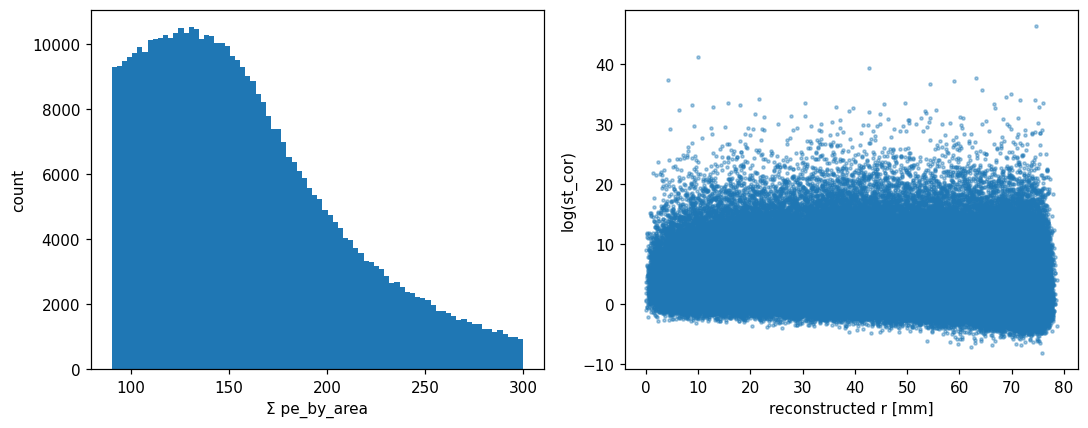

In [5]:
if pipe.cevns_points:
    arr = np.concatenate(pipe.cevns_points)
    area = arr['pe_by_area'].sum(axis=1)
    rec_x = arr['pos_recon']['xd']
    rec_y = arr['pos_recon']['yd']
    rec_r = np.sqrt(rec_x**2 + rec_y**2)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(area, bins=80)
    axes[0].set_xlabel('Σ pe_by_area'); axes[0].set_ylabel('count')
    axes[1].scatter(rec_r, np.log(np.maximum(arr['st_cor'], 1e-30)), s=4, alpha=0.4)
    axes[1].set_xlabel('reconstructed r [mm]'); axes[1].set_ylabel('log(st_cor)')
    plt.tight_layout(); plt.show()

## 4 – Save

In [6]:
pipe.save('outputs/cevns_sim/notebook_demo')

PosixPath('outputs/cevns_sim/notebook_demo')